# Быстрый старт

Ниже приведен ряд максимально быстрого и простого использования библиотеки genesis.

:::{.callout-note}
## Прим.

Целевыми объектами являются `узлы графа` улично-дорожной сети. Примеры расчета для `зданий` рассмотрены в основных разделах документации.

:::

## Расчет оптимальной дислокации одной ПСЧ (BLP)

Расчет осуществляется с использованием `алгоритма обезьяньего поиска (MSA)`. Целевой функцией является среднее время прибытия пожарного подразделения в любую точку графа улично-дорожной сети. Используется стандартный `скоростной режим` (`DEFAULT_SPEEDS = [49, 37, 26, 16, 5]` км/ч).

Наиболее выгодная точка размещения: 1577701962
Среднее время следования в любую точку города: 4.110610741363095 мин


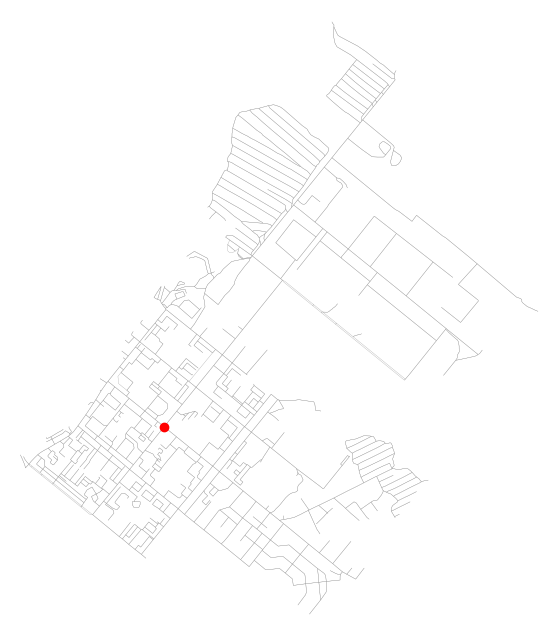

In [ ]:
import osmnx as ox

from genesis.best_points import BestNodeMonkey
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from graphs.speeds import kmh_to_mm, set_graph_travel_times
from fire_units.settings import DEFAULT_SPEEDS

# Загрузка ГДС
G = ox.graph_from_place(
    query        = 'Сосновоборск, Красноярский край, Россия',
    simplify     = False,
    network_type = 'drive_service')

# Установка скоростного режима
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

# Упрощаем граф для ускорения расчета
G = ox.simplify_graph(G)

# Использование алгоритма Обезьяньего поиска
blp = BestNodeMonkey(
    state_function  = FirstArrivalUnitState(),
    metric_function = ArrivalTime(),
    )

# Расчет лучшего размещения
best_node, best_metric = blp(G)

# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Визуализация ГДС с оптимальной точкой размещения
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='red');

Визуализация поверх карты местности

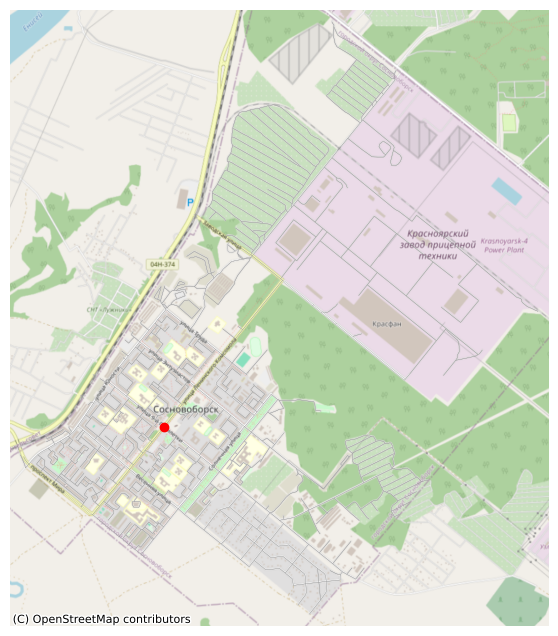

In [16]:
import contextily as ctx


fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='red')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=G.graph['crs']);

## Расчет оптимальной дислокации 2 подразделений (MCLP)

### Без учета существующих подразделений


Наиболее выгодные точки размещения:
osmid
1555151952    POINT (93.33406 56.11901)
2034401285    POINT (93.34948 56.13437)
Name: geometry, dtype: geometry
Среднее время следования в любую точку города: 3.4604699738910747 мин


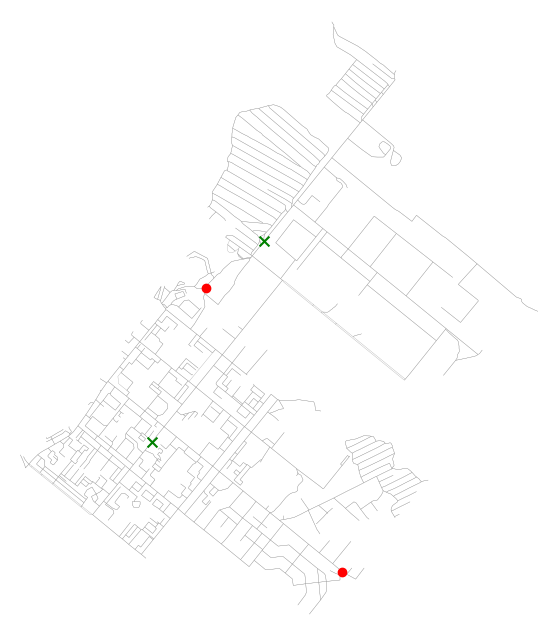

In [ ]:
import osmnx as ox

from genesis.best_points import BestNodeMonkey
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from graphs.speeds import kmh_to_mm, set_graph_travel_times
from fire_units.settings import DEFAULT_SPEEDS
from genesis.mclp import BestNodesGA
from genesis.point_selectors import RandomNodesSelector

# Загрузка ГДС
G = ox.graph_from_place(
    query        = 'Сосновоборск, Красноярский край, Россия',
    simplify     = False,
    network_type = 'drive_service')

# Установка скоростного режима
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

# Упрощаем граф для ускорения расчета
G = ox.simplify_graph(G)



# Создание стартового (произвольного) размещения ПСЧ
nodes = list(G.nodes())
start_nodes = {
    nodes[10]: 'псч 1',
    nodes[20]: 'псч 2',
}

# Использование Генетического алгоритма
mclp = BestNodesGA(
    state_function     = FirstArrivalUnitState(),
    metric_function    = ArrivalTime(),
    node_selector      = RandomNodesSelector(),
    mutation_max_count = 2,
    population_size    = 50,
    elite_size         = 15,
    epoch_end_function = lambda epoch, best_metric, **kwargs: print(epoch, best_metric, ' '*5, end='\r'),
)
print('')

# Расчет лучшего размещения
best_nodes, best_metric = mclp(
    env           = G,
    dynamic_nodes = start_nodes)

# Печать результата
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
print('Наиболее выгодные точки размещения:')
print(nodes_gdf.loc[best_nodes.keys()].geometry)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Визуализация ГДС с оптимальной точкой размещения
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
nodes_gdf.loc[start_nodes.keys()].plot(ax=ax, color='r', label='Исходное размещение')
nodes_gdf.loc[best_nodes.keys()].plot(ax=ax, color='g', label='Итоговое размещение', marker='x', markersize=50);

### С учетом существующих подразделений


Наиболее выгодные точки размещения:
osmid
426923846     POINT (93.33099 56.1169)
426923850    POINT (93.34331 56.11672)
Name: geometry, dtype: geometry
Среднее время следования в любую точку города: 3.088321685207403 мин


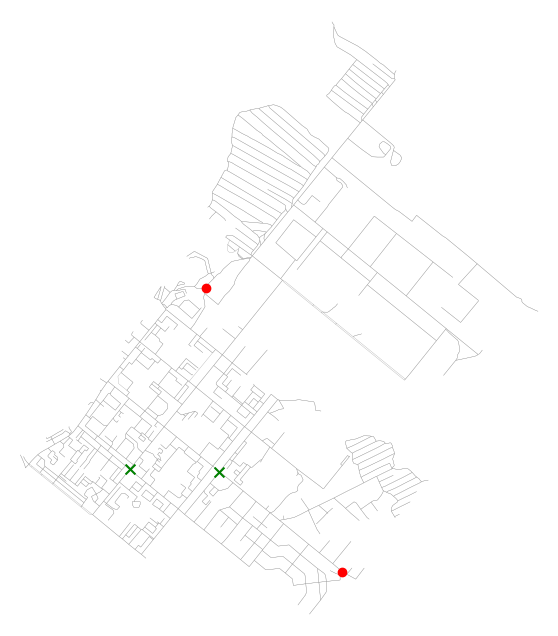

In [ ]:
import osmnx as ox

from genesis.best_points import BestNodeMonkey
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from graphs.speeds import kmh_to_mm, set_graph_travel_times
from fire_units.settings import DEFAULT_SPEEDS
from genesis.mclp import BestNodesGA
from genesis.point_selectors import RandomNodesSelector

# Загрузка ГДС
G = ox.graph_from_place(
    query        = 'Сосновоборск, Красноярский край, Россия',
    simplify     = False,
    network_type = 'drive_service')

# Установка скоростного режима
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

# Упрощаем граф для ускорения расчета
G = ox.simplify_graph(G)



# Создание стартового (произвольного) размещения ПСЧ
nodes = list(G.nodes())
start_nodes = {
    nodes[10]: 'псч 1',
    nodes[20]: 'псч 2',
}
# Создание размещения существующих подразделений (условно)
existing_nodes = {
    nodes[200]: 'ПСЧ 10',
    nodes[400]: 'ПСЧ 20',
}

# Использование Генетического алгоритма
mclp = BestNodesGA(
    state_function     = FirstArrivalUnitState(),
    metric_function    = ArrivalTime(),
    node_selector      = RandomNodesSelector(),
    mutation_max_count = 2,
    population_size    = 50,
    elite_size         = 15,
    epoch_end_function = lambda epoch, best_metric, **kwargs: print(epoch, best_metric, ' '*5, end='\r'),
)
print('')

# Расчет лучшего размещения
best_nodes, best_metric = mclp(
    env           = G,
    dynamic_nodes = start_nodes,
    static_nodes  = existing_nodes)

# Печать результата
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
print('Наиболее выгодные точки размещения:')
print(nodes_gdf.loc[best_nodes.keys()].geometry)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Визуализация ГДС с оптимальной точкой размещения
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
nodes_gdf.loc[existing_nodes.keys()].plot(ax=ax, color='k', label='Существующие ПСЧ', marker='*', markersize=50)
nodes_gdf.loc[start_nodes.keys()].plot(ax=ax, color='r', label='Исходное размещение')
nodes_gdf.loc[best_nodes.keys()].plot(ax=ax, color='g', label='Итоговое размещение', marker='x', markersize=50);

In [ ]:
times, nearest = FirstArrivalUnitState()(G, best_nodes)
nodes_gdf[nearest] = nearest

# Визуализация ГДС с оптимальной точкой размещения
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
nodes_gdf.plot(ax=ax, column='nearest', legend=True)
nodes_gdf.loc[existing_nodes.keys()].plot(ax=ax, color='k', label='Существующие ПСЧ', marker='*', markersize=50)
nodes_gdf.loc[start_nodes.keys()].plot(ax=ax, color='r', label='Исходное размещение')
nodes_gdf.loc[best_nodes.keys()].plot(ax=ax, color='g', label='Итоговое размещение', marker='x', markersize=50);

In [30]:
nodes_gdf

,y,x,street_count,highway,geometry
osmid,,,,,
360828220,56.123718,93.368673,2,NaN,POINT (93.36867 56.12372)
426923792,56.131361,93.351962,4,NaN,POINT (93.35196 56.13136)
426923793,56.113438,93.325914,4,NaN,POINT (93.32591 56.11344)
426923803,56.124114,93.347120,1,NaN,POINT (93.34712 56.12411)
426923806,56.113892,93.337655,4,traffic_signals,POINT (93.33765 56.11389)
...,...,...,...,...,...
12478138767,56.119344,93.319545,2,NaN,POINT (93.31954 56.11934)
12478138771,56.118818,93.320717,3,NaN,POINT (93.32072 56.11882)
12478138772,56.119977,93.321894,1,NaN,POINT (93.32189 56.11998)


In [31]:
nearest

426923846     псч 2
426923850     псч 1
1998227418    псч 2
1644098180    псч 2
2972894374    псч 2
              ...  
4116038493    псч 2
2034401801    псч 2
4116032430    псч 2
4116035752    псч 2
4116035978    псч 2
Name: nearest, Length: 649, dtype: object

In [ ]:
import pandas as pd

pd.merge(nodes_gdf, nearest, left_index=True, right_index=True)

,y,x,street_count,highway,geometry,nearest
360828220,56.123718,93.368673,2,NaN,POINT (93.36867 56.12372),псч 2
426923792,56.131361,93.351962,4,NaN,POINT (93.35196 56.13136),псч 2
426923793,56.113438,93.325914,4,NaN,POINT (93.32591 56.11344),псч 2
426923803,56.124114,93.347120,1,NaN,POINT (93.34712 56.12411),псч 2
426923806,56.113892,93.337655,4,traffic_signals,POINT (93.33765 56.11389),псч 1
...,...,...,...,...,...,...
12478138767,56.119344,93.319545,2,NaN,POINT (93.31954 56.11934),псч 2
12478138771,56.118818,93.320717,3,NaN,POINT (93.32072 56.11882),псч 2
12478138772,56.119977,93.321894,1,NaN,POINT (93.32189 56.11998),псч 2
12478138775,56.119389,93.320195,3,NaN,POINT (93.3202 56.11939),псч 2


## Расчет оптимальной дислокации и требуемого количества подразделений (LSCP)